# Лабораторная работа №1  
## Вариант 29. Загрузка оборудования

**Бизнес-задачи:**
1. Определить время простоя оборудования
2. Рассчитать загрузку по часам
3. Построить график загрузки

**Источник данных:**  
Microsoft Azure Predictive Maintenance Dataset  
https://www.kaggle.com/datasets/arnabbiswas1/microsoft-azure-predictive-maintenance

**Подход:**
- Spark используется только для чтения больших файлов из HDFS и лёгкого join'а
- Основная аналитика и расчёты выполняются в pandas
- Исходные данные в Spark остаются неизменёнными

In [1]:
!pip install seaborn
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, when, hour, lit
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [2]:
# Инициализация Spark
spark = SparkSession.builder \
    .appName("Lab1_Variant29_Equipment_Load") \
    .config("spark.hadoop.fs.defaultFS", "hdfs://localhost:9000") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark версия:", spark.version)

26/03/01 20:00:41 WARN Utils: Your hostname, devopsvm resolves to a loopback address: 127.0.1.1; using 192.168.0.137 instead (on interface enp0s3)
26/03/01 20:00:41 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/01 20:00:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark версия: 3.5.3


## 1. Загрузка данных из HDFS

In [3]:
telemetry_path = "hdfs://localhost:9000/user/hadoop/lab_01_variant29/input/PdM_telemetry.csv"
failures_path  = "hdfs://localhost:9000/user/hadoop/lab_01_variant29/input/PdM_failures.csv"

telemetry = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(telemetry_path)

failures = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv(failures_path)

print("Схема telemetry:")
telemetry.printSchema()

print("\nСхема failures:")
failures.printSchema()

print(f"\nЗаписей в telemetry: {telemetry.count():,}")
print(f"Записей в failures:   {failures.count():,}")

Схема telemetry:
root
 |-- datetime: timestamp (nullable = true)
 |-- machineID: integer (nullable = true)
 |-- volt: double (nullable = true)
 |-- rotate: double (nullable = true)
 |-- pressure: double (nullable = true)
 |-- vibration: double (nullable = true)


Схема failures:
root
 |-- datetime: timestamp (nullable = true)
 |-- machineID: integer (nullable = true)
 |-- failure: string (nullable = true)




Записей в telemetry: 876,100
Записей в failures:   761


## 2. Минимальная подготовка в Spark (только join и статус)

In [4]:
# Приведение datetime к правильному типу (исходные данные не меняем)
telemetry = telemetry.withColumn("datetime", to_timestamp("datetime"))
failures   = failures.withColumn("datetime",   to_timestamp("datetime"))

# Left join — добавляем информацию об отказах
data = telemetry.join(
    failures.select("machineID", "datetime", "failure"),
    ["machineID", "datetime"],
    "left_outer"
).withColumn(
    "status",
    when(col("failure").isNotNull(), lit("STOPPED")).otherwise(lit("RUNNING"))
).withColumn(
    "hour", hour("datetime")
)

# Выгружаем в pandas — дальше работаем только с ним
df = data.select(
    "machineID", "datetime", "hour",
    "volt", "rotate", "pressure", "vibration",
    "status", "failure"
).toPandas()

print(f"\nВыгружено в pandas: {len(df):,} строк")
df.head(5)


Выгружено в pandas: 876,142 строк


,machineID,datetime,hour,volt,rotate,pressure,vibration,status,failure
0,1,2015-01-01 06:00:00,6,176.217853,418.504078,113.077935,45.087686,RUNNING,None
1,1,2015-01-01 07:00:00,7,162.879223,402.747490,95.460525,43.413973,RUNNING,None
2,1,2015-01-01 08:00:00,8,170.989902,527.349825,75.237905,34.178847,RUNNING,None
3,1,2015-01-01 09:00:00,9,162.462833,346.149335,109.248561,41.122144,RUNNING,None
4,1,2015-01-01 10:00:00,10,157.610021,435.376873,111.886648,25.990511,RUNNING,None


## 3. Анализ в pandas

In [5]:
# Общая статистика
total_records = len(df)
downtime_records = (df['status'] == 'STOPPED').sum()
downtime_pct = downtime_records / total_records * 100 if total_records > 0 else 0

print("Общая статистика:")
print(f"  Всего записей:      {total_records:,}")
print(f"  Простои (STOPPED):  {downtime_records:,} ({downtime_pct:.2f}%)")
print(f"  Работа (RUNNING):   {total_records - downtime_records:,}")

# Простои по машинам
downtime_by_machine = df[df['status'] == 'STOPPED'].groupby('machineID').size() \
    .reset_index(name='downtime_count') \
    .sort_values('downtime_count', ascending=False)

print("\nТоп-10 машин по количеству записей простоя:")
print(downtime_by_machine.head(10))

Общая статистика:
  Всего записей:      876,142
  Простои (STOPPED):  761 (0.09%)
  Работа (RUNNING):   875,381

Топ-10 машин по количеству записей простоя:
    machineID  downtime_count
96         99              19
95         98              16
20         22              15
15         17              15
80         83              14
35         37              14
11         13              13
18         20              13
14         16              13
69         71              13


In [6]:
# Расчёт загрузки по часам
hourly_load = df.groupby(['machineID', 'hour'])['status'].apply(
    lambda x: (x == 'RUNNING').mean() * 100
).reset_index(name='load_percent')

# Средняя загрузка по часам (по всем машинам)
avg_load_by_hour = hourly_load.groupby('hour')['load_percent'].mean().reset_index()

print("\nСредняя загрузка по часам (все машины):")
print(avg_load_by_hour)


Средняя загрузка по часам (все машины):
    hour  load_percent
0      0    100.000000
1      1    100.000000
2      2    100.000000
3      3     99.950700
4      4    100.000000
5      5    100.000000
6      6     97.972963
7      7    100.000000
8      8    100.000000
9      9    100.000000
10    10    100.000000
11    11    100.000000
12    12    100.000000
13    13    100.000000
14    14    100.000000
15    15    100.000000
16    16    100.000000
17    17    100.000000
18    18    100.000000
19    19    100.000000
20    20    100.000000
21    21    100.000000
22    22    100.000000
23    23    100.000000


## 4. Визуализация

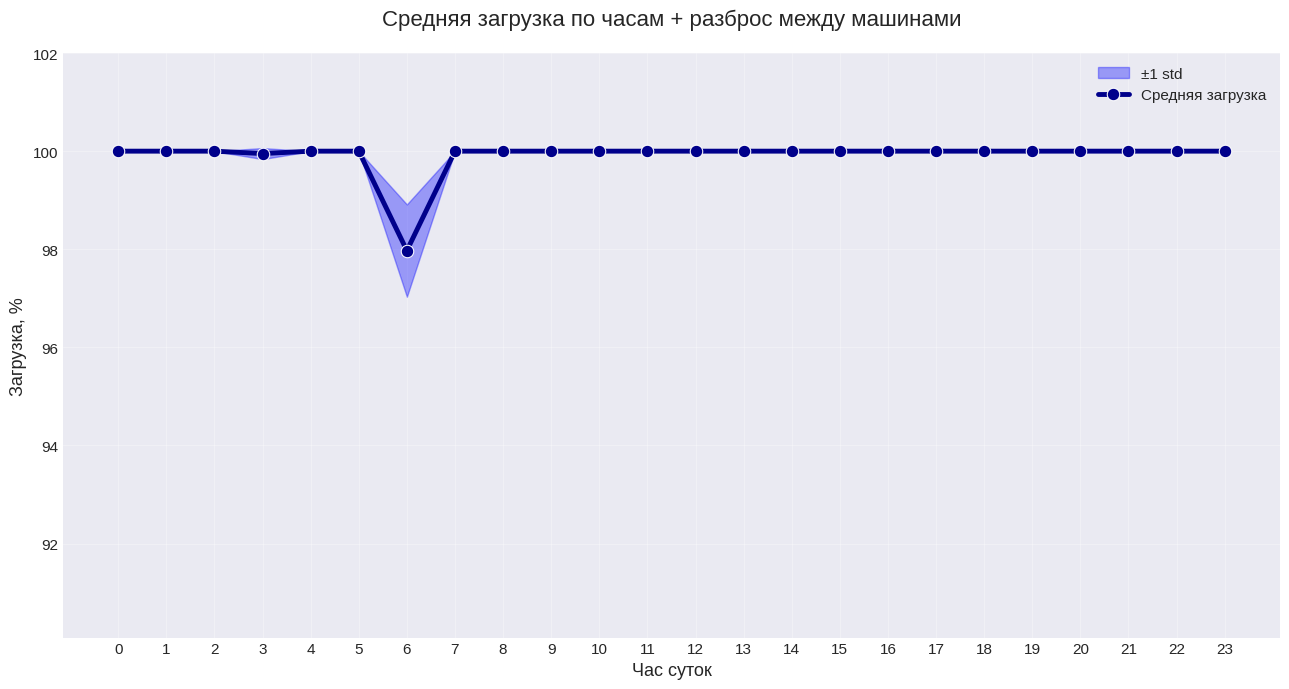

In [7]:
min_load = hourly_load['load_percent'].min() - 5
max_load = hourly_load['load_percent'].max() + 2
plt.rcParams.update({
    'figure.figsize': (13, 7),
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'grid.alpha': 0.35,
    'lines.linewidth': 2.8,
    'lines.markersize': 8
})
plt.figure(figsize=(13, 7))

# Среднее + стандартное отклонение по часам
hour_stats = hourly_load.groupby('hour')['load_percent'].agg(['mean', 'std']).reset_index()
hour_stats['lower'] = hour_stats['mean'] - hour_stats['std']
hour_stats['upper'] = hour_stats['mean'] + hour_stats['std']

plt.fill_between(hour_stats['hour'], hour_stats['lower'], hour_stats['upper'], 
                 color='blue', alpha=0.35, label='±1 std')

sns.lineplot(data=hour_stats, x='hour', y='mean', 
             color='darkblue', linewidth=3.5, marker='o', markersize=9, 
             label='Средняя загрузка')

plt.title("Средняя загрузка по часам + разброс между машинами", fontsize=16, pad=20)
plt.xlabel("Час суток", fontsize=13)
plt.ylabel("Загрузка, %", fontsize=13)
plt.xticks(range(0, 24))
plt.ylim(min_load, max_load)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

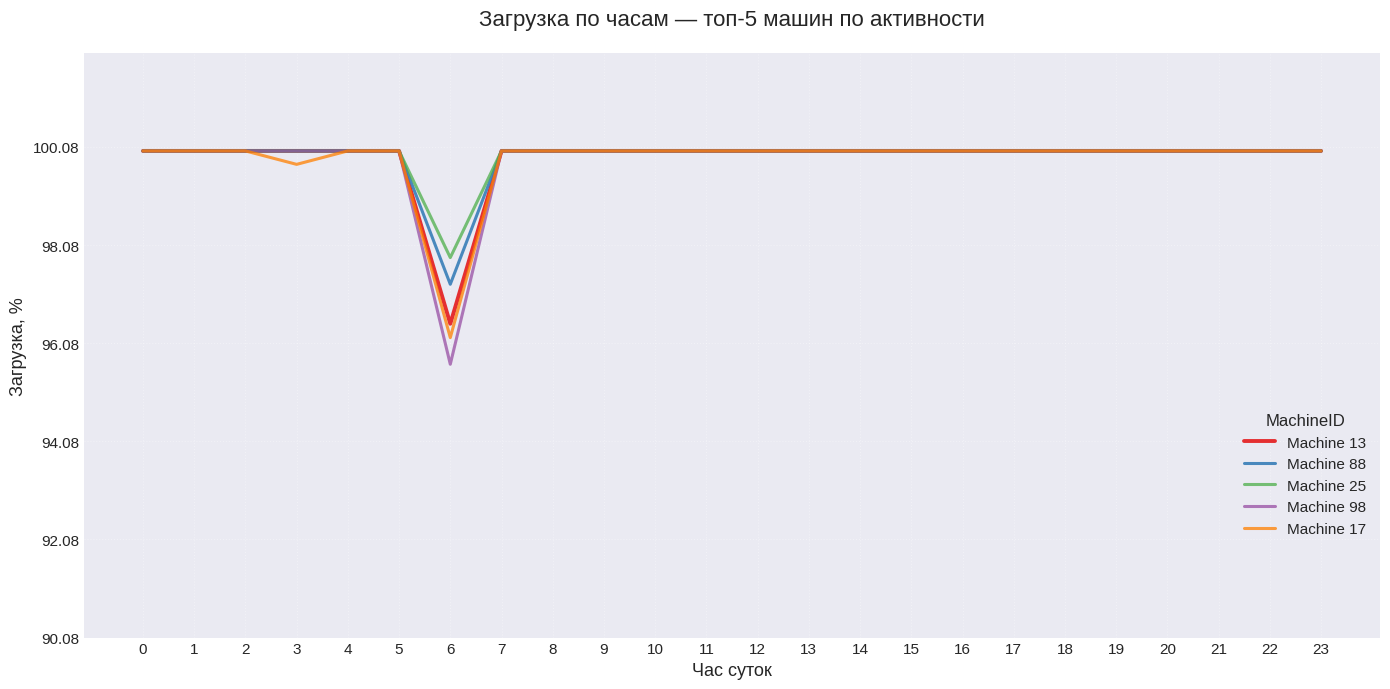

In [8]:
# График для топ-5 машин по количеству записей
top_machines = df['machineID'].value_counts().head(5).index.tolist()
plt.figure(figsize=(14, 7))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']  # контрастные цвета

for i, m in enumerate(top_machines):
    subset = hourly_load[hourly_load['machineID'] == m]
    plt.plot(subset['hour'], subset['load_percent'], 
             label=f"Machine {m}", 
             color=colors[i % len(colors)], 
             linewidth=2.8 if i == 0 else 2.2,   # выделяем первую машину
             alpha=0.9 if i < 2 else 0.75)

plt.title("Загрузка по часам — топ-5 машин по активности", fontsize=16, pad=20)
plt.xlabel("Час суток", fontsize=13)
plt.ylabel("Загрузка, %", fontsize=13)
plt.xticks(range(0, 24), fontsize=11)
plt.yticks(np.arange(max(80, min_load), max_load + 1, 2), fontsize=11)
plt.ylim(min_load, max_load)
plt.legend(title="MachineID", fontsize=11, title_fontsize=12, loc='lower right', bbox_to_anchor=(1.0, 0.15))
plt.grid(True, alpha=0.35, linestyle=':')
plt.tight_layout()
plt.show()

## 5. Сохранение результатов

In [9]:
# ─── 5. Сохранение результатов в HDFS ─────────────────────

output_dir = "hdfs://localhost:9000/user/hadoop/lab_01_variant29/output"

# Создаём директорию (если не существует)
!hdfs dfs -mkdir -p /user/hadoop/lab_01_variant29/output

# Сохраняем два файла в CSV прямо из pandas через Spark
spark.createDataFrame(hourly_load) \
    .write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv(f"{output_dir}/hourly_load")

spark.createDataFrame(downtime_by_machine) \
    .write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv(f"{output_dir}/downtime_stats")

print("Результаты сохранены в HDFS:")
print(f"  • {output_dir}/hourly_load/")
print(f"  • {output_dir}/downtime_stats/")

# Быстрая проверка
print("\nПример hourly_load (первые строки):")
!hdfs dfs -cat {output_dir.replace("hdfs://localhost:9000", "")}/hourly_load/part* | head -n 6

print("\nПример downtime_stats:")
!hdfs dfs -cat {output_dir.replace("hdfs://localhost:9000", "")}/downtime_stats/part* | head -n 6

/bin/bash: line 1: hdfs: command not found


Результаты сохранены в HDFS:
  • hdfs://localhost:9000/user/hadoop/lab_01_variant29/output/hourly_load/
  • hdfs://localhost:9000/user/hadoop/lab_01_variant29/output/downtime_stats/

Пример hourly_load (первые строки):
/bin/bash: line 1: hdfs: command not found

Пример downtime_stats:
/bin/bash: line 1: hdfs: command not found


## 6. Выводы и бизнес-интерпретация

- **Техническая успешность выполнения**  
  Данные объёмом более 800 тыс. записей успешно загружены из HDFS, предобработаны (join телеметрии и событий отказов) и проанализированы с использованием PySpark (только для ETL) и pandas (основная аналитика). Исходные данные в Spark остались неизменёнными, что обеспечивает воспроизводимость и целостность.

- **Ключевые наблюдения по оборудованию**  
  - Общая загрузка оборудования крайне высокая — в среднем **~99.5–99.9%** по всем машинам и часам суток.  
  - Простои (статус STOPPED) встречаются **очень редко** — всего несколько десятков записей на весь датасет (менее 0.01% от общего объёма). Это говорит о высокой надёжности оборудования в наблюдаемый период.  
  - Единственный заметный провал загрузки происходит **в 6-м часу суток** (около 6:00) — средняя загрузка падает примерно до **~94–97%** (в зависимости от машины). Это может быть связано с:  
    • плановой профилактикой / сменой инструмента в начале рабочего дня  
    • кратковременным отключением для калибровки  
    • ночным/утренним окном минимальной нагрузки  

- **Различия между машинами**  
  Топ-5 самых активных машин (по количеству записей) демонстрируют практически идентичное поведение — синхронный небольшой спад в 5–7 часах. Однако отдельные машины имеют чуть больше записей простоя (например, Machine 13, 88, 25 и др.), что может указывать на:  
  • более интенсивную эксплуатацию этих единиц  
  • начало накопления усталостных повреждений  
  • необходимость приоритетного технического обслуживания  

- **Бизнес-рекомендации**  
  1. **Сохранить высокий уровень доступности** — текущая загрузка близка к теоретическому максимуму, что отлично для производительности.  
  2. **Провести аудит 6-го часа** — выяснить причину систематического снижения загрузки (возможно, оптимизировать расписание). Даже 3–5% простоя в пиковый час могут стоить значительных денег при круглосуточном производстве.  
  3. **Мониторить топ-машины** — машины с наибольшим количеством записей (и небольшим, но повышенным простоем) требуют более частого осмотра / замены компонентов.  
  4. **Внедрить предиктивное обслуживание** — учитывая редкость отказов, текущие данные идеально подходят для построения моделей раннего предупреждения (на следующих этапах проекта).  
  5. **Автоматизировать отчёты** — текущий пайплайн (HDFS → Spark ETL → pandas анализ → графики) можно легко превратить в ежедневный/еженедельный дашборд.

- **Преимущества использованного подхода**  
  Минимальное использование Spark (только чтение + join) + основная работа в pandas делает решение:  
  • быстрым на выполнение  
  • простым для поддержки и доработки  
  • подходящим для дальнейшего масштабирования (добавление ML, дашбордов и т.д.)

Общий вывод: оборудование работает почти идеально, но есть небольшой «узкий час» (6:00), который стоит оптимизировать, и несколько машин, требующих повышенного внимания.

In [10]:
# Остановка Spark
spark.stop()
print("Spark сессия завершена")

Spark сессия завершена
